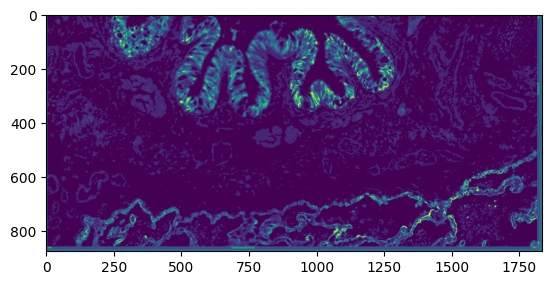

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('Image5.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img)





In [3]:
# Applying preprocessing step
for  y in range(len(img)):
    for x in range(len(img[0])):
      
        if img[y][x]  < 30:  # Adjusting the pixel intensity as needed
            img[y][x] = 0



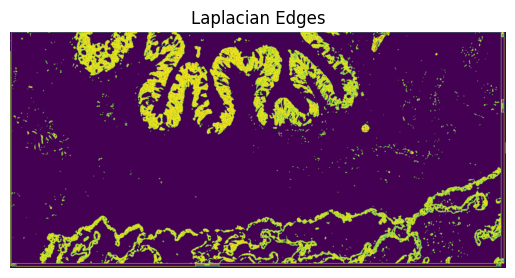

In [4]:
# Apply Laplacian edge detection
laplace = cv2.Laplacian(img, cv2.CV_64F)
laplace = cv2.convertScaleAbs(laplace)

#Negate the Laplacian to enhance edges
plt.imshow(-laplace)
plt.title("Laplacian Edges")
plt.axis('off')
plt.show()


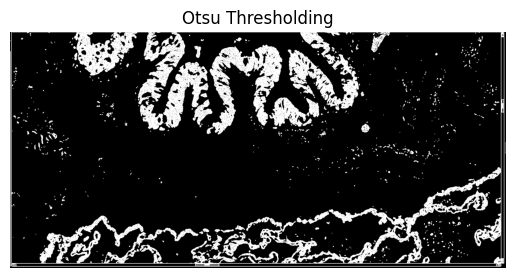

In [5]:
# Convert to binary using Otsu threshold on the negated Laplacian
_, thresh = cv2.threshold(-laplace, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(thresh, cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')
plt.show()

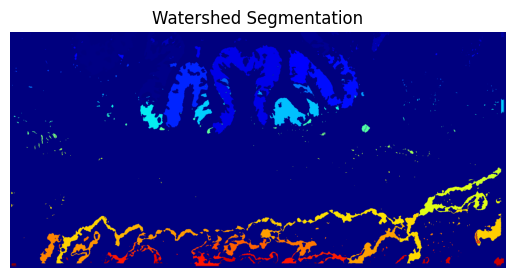

In [6]:


# Distance transform to find sure foreground
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.2 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Background region
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(thresh, kernel, iterations=3)

# Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Labelling the sure foreground markers
_, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1
markers[unknown == 255] = 0

# Watershed segmentation process
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
markers = cv2.watershed(img_color, markers)

# Visualize the watershed segmentation result
plt.imshow(markers, cmap='jet')
plt.title("Watershed Segmentation")
plt.axis('off')
plt.show()

In [7]:
# Refining the watershed model using fourier descriptors
contour_list = list()
length_list = list()
img_color = cv2.imread('Image5.png', cv2.IMREAD_COLOR_RGB)

MAX_LEN = 3000 # gets rid of entire picture level contour (no reason as to the exact number)
MIN_LEN = 20 #placeholder for now

# Loop through each unique marker label (except for -1 and 1 which represent boundaries and background)
for label in np.unique(markers):
    if label == -1 or label == 1:
        continue
# Create a binary mask for the current marker label
    mask = np.zeros_like(markers, dtype=np.uint8)
    mask[markers == label] = 255
# Find contours in the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        continue
    contour = contours[0]
# Convert contour points to complex numbers for Fourier analysis
    contour_complex = np.empty(contour.shape[0], dtype=complex)
    for i in range(contour.shape[0]):
        contour_complex[i] = complex(contour[i][0][0], contour[i][0][1])
# Perform Fourier Transform and keep only the first n_descriptors coefficients
    fourier_result = np.fft.fft(contour_complex)
    # Use a fixed number of descriptors to reconstruct the contour (adjust as needed)
    k = 70 
    # Truncate the Fourier coefficients to keep only the first k descriptors
    fourier_result[k:-k] = 0
    # Reconstruct the contour from the truncated Fourier coefficients
    contour_reconstructed = np.fft.ifft(fourier_result)
# Convert the reconstructed contour back to integer coordinates
    contour_reconstructed = np.array([[int(pt.real), int(pt.imag)] for pt in contour_reconstructed], dtype=np.int32)
    # Filter contours based on length and draw them on the original image
    if len(contour_reconstructed) < MAX_LEN and len(contour_reconstructed) > MIN_LEN:
        contour_list.append(contour_reconstructed)
        length_list.append(len(contour_reconstructed))
        cv2.drawContours(img_color, [contour_reconstructed], -1, (0, 255, 0), 2)

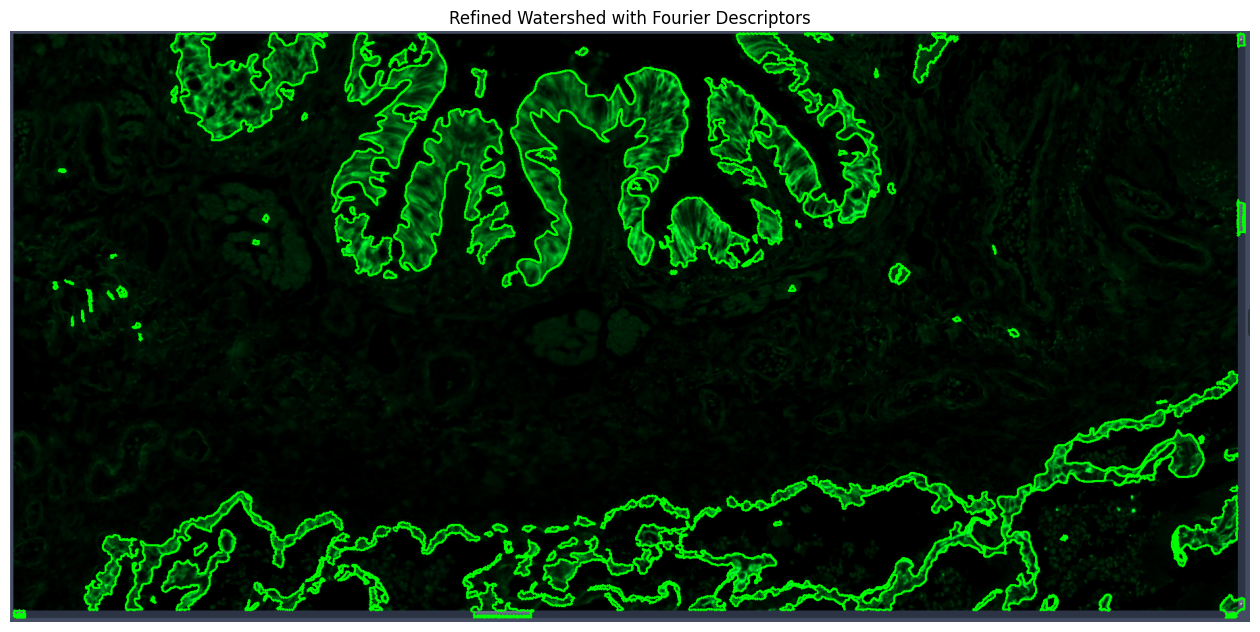

In [8]:
# Visualize the refined watershed segmentation result
plt.figure(figsize=(16,16))
plt.imshow(img_color, cmap='gray')
plt.title("Refined Watershed with Fourier Descriptors")
plt.axis('off')
plt.show()

In [11]:

import pandas as pd

# Function to describe contours and calculate area and cell count
def describe_contours(contour_list, gray_img):
    areas = []
    
    #loop through each contour and calculate area
    for contour in contour_list:
        area = cv2.contourArea(contour)
        areas.append(area)
        # Mask the contour area to calculate intensity statistics if needed (not implemented here but can be added)
        mask = np.zeros(gray_img.shape, dtype=np.uint8)
        cv2.fillPoly(mask, [contour], 255)
    
        
    # Convert areas to a numpy array for easier calculations
    areas = np.array(areas)

    
  #Printing the cell count by finding the total number of contours
    print(f"Total structures detected: {len(contour_list)}")
    #Printing area statistics such as total area, mean area, and standard deviation of area
    print(f"\nArea (pixels):")
    print(f"  Total Area: {areas.sum():.2f}")
    print(f"  Mean Area: {areas.mean():.2f}")
    print(f"  Std of Area: {areas.std():.2f}")
    

 
describe_contours(contour_list, img)




Total structures detected: 153

Area (pixels):
  Total Area: 186896.00
  Mean Area: 1221.54
  Std of Area: 3609.65


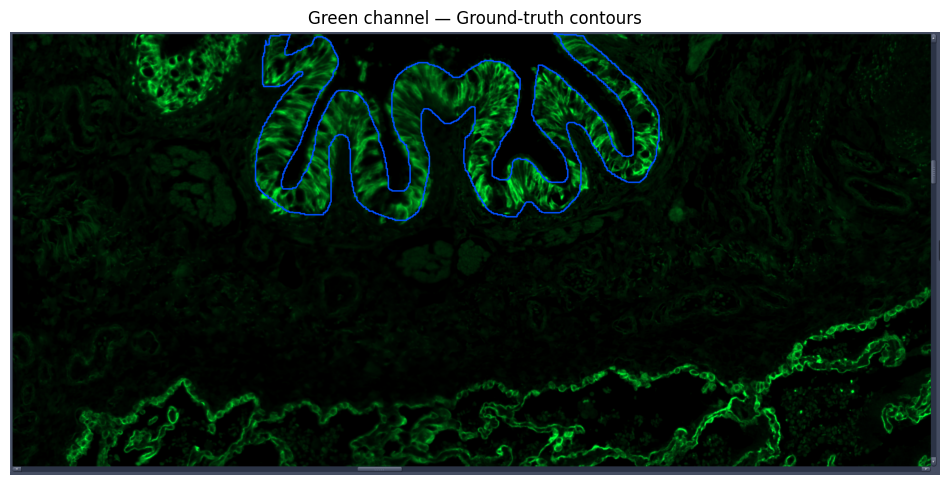

In [ ]:
# Load original green channel image
img = cv2.imread("Image5.png", cv2.IMREAD_COLOR)
overlay = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load ground-truth contours from CSV
gt_df = pd.read_csv("green_gt.csv")

# Draw each contour in blue
for cid in gt_df["contour_id"].unique():
    pts = gt_df[gt_df["contour_id"] == cid][["x", "y"]].values.astype(np.int32)
    if len(pts) >= 3:
        cv2.polylines(overlay, [pts.reshape(-1, 1, 2)], True, (0, 80, 255), 2)

# Display image
plt.figure(figsize=(12, 6))
plt.imshow(overlay)
plt.title("Green channel — Ground-truth contours")
plt.axis("off")
plt.show()

